# Mask vs. Delete Ablation Comparison for Random and LLM Spans

This notebook compares **masking** and **deletion** while keeping the selected spans fixed. It uses the already available masking scores and computes only the missing deletion scores.

The analysis answers the following questions:

1. Does deleting the selected spans reduce the model's inappropriateness probability more strongly than masking them?
2. How often does each ablation produce a positive probability drop?
3. Are the differences consistent at the argument level?
4. Do conclusions differ between random spans and LLM-selected spans?

The notebook creates per-argument result files, summary tables, paired statistical comparisons, and publication-ready plots.

## Evaluation design and important assumptions

- The LLM file contains test-set true positives. For a fair comparison, random results are therefore filtered to test true positives by default.
- Mask and delete are evaluated on the **same selected character spans**. Only the replacement operation changes.
- Existing masking probabilities are reused. The classifier is run only for the newly generated deleted texts.
- If random spans contain several `sample_id` repetitions for one argument, row-level results are retained, but the primary summaries and statistical tests aggregate them by `global_row_id`. This avoids treating repeated random samples as independent arguments.
- The model input format is inferred by comparing recomputed masking probabilities against the stored masking probabilities. Review the reported mean absolute error before trusting the deletion results.
- Probability drop is defined as:

$$ \Delta p = p(\mathrm{inappropriate}\mid x) - p(\mathrm{inappropriate}\mid x_{\mathrm{perturbed}}) $$

A positive value means that removing the selected evidence reduced the model's inappropriateness score.

In [1]:
from __future__ import annotations

import ast
import json
import math
import re
import warnings
from pathlib import Path
from typing import Any, Iterable, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

try:
    from scipy.stats import wilcoxon
except ImportError:
    wilcoxon = None
    warnings.warn("scipy is not installed. Wilcoxon tests will be skipped.")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)

# Reproducible bootstrap confidence intervals.
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [2]:
# -----------------------------------------------------------------------------
# Paths and evaluation configuration
# -----------------------------------------------------------------------------

RANDOM_RESULTS_PATH = Path(
    "results/random_baseline_results/random_best_config_test_per_argument.csv"
)
LLM_RESULTS_PATH = Path(
    "results/llm_reference/llm_test_tp_spans_argument_level.csv"
)
OUTPUT_DIR = Path("results/ablation_comparison_random_llm")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Use the same classifier that produced the existing probabilities.
# Replace this value with a local checkpoint path when necessary.
MODEL_NAME_OR_PATH = "timonziegenbein/appropriateness-classifier-binary"

# The model usually predicts the inappropriate class at index 1.
# Set this explicitly if the model configuration does not contain informative labels.
INAPPROPRIATE_LABEL_ID = 1

BATCH_SIZE = 32
MAX_LENGTH = 512
PREDICTION_THRESHOLD = 0.5

# Fair comparison with the LLM file, which contains test true positives.
FILTER_RANDOM_TO_TEST_TP = True
FILTER_LLM_TO_VALID_ROWS = True

# When True, whitespace left behind by deletion is cleaned without otherwise
# changing the text content.
NORMALIZE_DELETED_WHITESPACE = True

# "auto" tests several common input formats against stored masking scores.
# Available explicit values:
#   - "pair_issue_argument"
#   - "argument_only"
#   - "concat_issue_argument"
MODEL_INPUT_MODE = "auto"
AUTO_INPUT_MODE_CANDIDATES = [
    "pair_issue_argument",
    "argument_only",
    "concat_issue_argument",
]
AUTO_MODE_SAMPLE_SIZE = 64

# Number of bootstrap resamples for 95% confidence intervals.
N_BOOTSTRAP = 2_000

print(f"Random input: {RANDOM_RESULTS_PATH}")
print(f"LLM input:    {LLM_RESULTS_PATH}")
print(f"Output dir:   {OUTPUT_DIR}")

Random input: results/random_baseline_results/random_best_config_test_per_argument.csv
LLM input:    results/llm_reference/llm_test_tp_spans_argument_level.csv
Output dir:   results/ablation_comparison_random_llm


In [3]:
# Load the existing results.
df_random_raw = pd.read_csv(RANDOM_RESULTS_PATH)
df_llm_raw = pd.read_csv(LLM_RESULTS_PATH)

print("Random results shape:", df_random_raw.shape)
print("LLM results shape:   ", df_llm_raw.shape)

display(df_random_raw.head(2))
display(df_llm_raw.head(2))

Random results shape: (438, 54)
LLM results shape:    (100, 33)


,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,is_false_positive,is_true_negative,attribution_method,span_selection_mode,span_length,sample_id,quantile,window_size,ablation_mode,p_inappropriate_original,p_inappropriate_perturbed,p_inappropriate_masked,predicted_label_perturbed,predicted_label_masked,prob_drop,n_model_tokens,n_words,n_selected_tokens,n_selected_words,selected_token_ratio,selected_word_ratio,n_merged_spans,total_masked_tokens,total_masked_chars,masked_token_ratio,selected_word_indices,selected_word_texts,selected_token_indices,selected_token_texts,merged_span_texts,merged_span_token_start_indices,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_words_json,selected_tokens_json,merged_spans_json,was_truncated,text,perturbed_text,masked_text,error,eval_scope,final_selection_type
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,0.892726,FN,False,True,False,False,random_baseline,multi_word_budgeted,25,0,NaN,NaN,mask,0.107274,0.434141,0.434141,LABEL_0,LABEL_0,-0.326867,12,12,12,12,1.0,1.0,1,12,69,1.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]","['students', ' should', ' wear', ' what', ' they', ' like', ' and', ' feel', ' free', ' about', ' their', ' clothes']","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","['▁students', '▁should', '▁wear', '▁what', '▁they', '▁like', '▁and', '▁feel', '▁free', '▁about', '▁their', '▁clothes']",['students should wear what they like and feel free about their clothes'],[1],[12],[0],[69],"[""students"", "" should"", "" wear"", "" what"", "" they"", "" like"", "" and"", "" feel"", "" free"", "" about"", "" their"", "" clothes""]","[""▁students"", ""▁should"", ""▁wear"", ""▁what"", ""▁they"", ""▁like"", ""▁and"", ""▁feel"", ""▁free"", ""▁about"", ""▁their"", ""▁clothes""]","[{""char_start"": 0, ""char_end"": 69, ""word_start_idx"": 0, ""word_end_idx"": 11, ""token_start_idx"": 1, ""token_end_idx"": 12, ""span_text"": ""students should wear wh...",False,students should wear what they like and feel free about their clothes,[MASK],[MASK],NaN,best_config_all_splits,single_random_sample_with_validation_selected_config
1,1754,test,8,Tv is better than books:,1,LABEL_1,0.997475,TP,True,False,False,False,random_baseline,multi_word_budgeted,25,0,NaN,NaN,mask,0.997475,0.434141,0.434141,LABEL_0,LABEL_0,0.563335,27,25,27,25,1.0,1.0,1,27,112,1.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]","['I', ' thick', ' that', ' book', ' are', ' better', ' than', ' TV', ' is', ' it', ' is', ' better', ' i', ' can', ' put', ' you', ' in', ' a', ' whole', ' ...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]","['▁I', '▁thick', '▁that', '▁book', '▁are', '▁better', '▁than', '▁TV', '▁is', '▁it', '▁is', '▁better', '▁i', '▁can', '▁put', '▁you', '▁in', '▁a', '▁whole', '...",['I thick that book are better than TV is it is better i can put you in a whole norther wold and it is educational'],[1],[27],[0],[112],"[""I"", "" thick"", "" that"", "" book"", "" are"", "" better"", "" than"", "" TV"", "" is"", "" it"", "" is"", "" better"", "" i"", "" can"", "" put"", "" you"", "" in"", "" a"", "" whole"", "" ...","[""▁I"", ""▁thick"", ""▁that"", ""▁book"", ""▁are"", ""▁better"", ""▁than"", ""▁TV"", ""▁is"", ""▁it"", ""▁is"", ""▁better"", ""▁i"", ""▁can"", ""▁put"", ""▁you"", ""▁in"", ""▁a"", ""▁whole"", ""...","[{""char_start"": 0, ""char_end"": 112, ""word_start_idx"": 0, ""word_end_idx"": 24, ""token_start_idx"": 1, ""token_end_idx"": 27, ""span_text"": ""I thick that book are ...",False,I thick that book are better than TV is it is better i can put you in a whole norther wold and it is educational,[MASK],[MASK],NaN,best_config_all_splits,single_random_sample_with_validation_selected_config


,global_row_id,post_id,split,issue,argument,label,p_inappropriate_original,llm_span_texts,llm_char_starts_original,llm_char_ends_original,llm_char_starts,llm_char_ends,llm_confidences,llm_raw_spans,llm_valid,n_llm_spans,llm_fixed_offsets,llm_errors,model_name,llm_valid_bool,confusion_type,total_tokens,n_selected_tokens,masked_token_ratio,masked_text,selected_token_texts,selected_token_indices,llm_char_spans_merged,llm_span_texts_from_offsets,p_inappropriate_masked,predicted_label_masked,prob_drop,positive_drop
0,1754,8,test,Tv is better than books:,I thick that book are better than TV is it is better i can put you in a whole norther wold and it is educational,1,0.997475,"['thick', 'norther wold']","[2, 61]","[7, 73]","[2, 78]","[7, 90]","[0.95, 0.95]","[{'span_text': 'thick', 'char_start': 2, 'char_end': 7, 'confidence': 0.95}, {'span_text': 'norther wold', 'char_start': 61, 'char_end': 73, 'confidence': 0...",True,2,"[False, True]","[None, None]",gemini-3-flash-preview,True,TP,27,5,0.185185,I [MASK] that book are better than TV is it is better i can put you in a whole [MASK] and it is educational,"[""▁thick"", ""▁north"", ""er"", ""▁w"", ""old""]","[1, 19, 20, 21, 22]","[[2, 7], [78, 90]]","[""thick"", ""norther wold""]",0.997596,1,-0.000121,False
1,1756,12,test,India has the potential to lead the world:,india is is good adopter but a bad developer and leader should be a great developer,1,0.995627,['india is is good adopter but a bad developer and leader should be a great developer'],[0],[83],[0],[83],[0.9],"[{'span_text': 'india is is good adopter but a bad developer and leader should be a great developer', 'char_start': 0, 'char_end': 83, 'confidence': 0.9}]",True,1,[False],[None],gemini-3-flash-preview,True,TP,16,16,1.000000,[MASK],"[""▁india"", ""▁is"", ""▁is"", ""▁good"", ""▁adopter"", ""▁but"", ""▁a"", ""▁bad"", ""▁developer"", ""▁and"", ""▁leader"", ""▁should"", ""▁be"", ""▁a"", ""▁great"", ""▁developer""]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]","[[0, 83]]","[""india is is good adopter but a bad developer and leader should be a great developer""]",0.434141,0,0.561486,True


## 1. Prepare comparable masking rows

The random file may contain an `ablation_mode` column even when the selected file stores only the best masking configuration. The following cell explicitly keeps masking rows and applies the test-TP filter. The LLM file is restricted to valid annotations.

In [4]:
def as_bool(series: pd.Series) -> pd.Series:
    """Convert common string/numeric boolean encodings to a Boolean series."""
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .isin({"true", "1", "yes", "y", "t"})
    )


def filter_random_mask_rows(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "ablation_mode" in out.columns:
        mask_rows = out["ablation_mode"].astype(str).str.lower().eq("mask")
        if mask_rows.any():
            out = out.loc[mask_rows].copy()
        else:
            warnings.warn(
                "No rows with ablation_mode='mask' were found. All rows are retained."
            )

    if "split" in out.columns:
        out = out.loc[out["split"].astype(str).str.lower().eq("test")].copy()

    if FILTER_RANDOM_TO_TEST_TP:
        if "confusion_type" in out.columns:
            out = out.loc[
                out["confusion_type"].astype(str).str.upper().eq("TP")
            ].copy()
        elif "is_true_positive" in out.columns:
            out = out.loc[as_bool(out["is_true_positive"])].copy()
        else:
            warnings.warn(
                "No TP indicator was found in the random file. No TP filter was applied."
            )

    return out.reset_index(drop=True)


def filter_llm_rows(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "split" in out.columns:
        out = out.loc[out["split"].astype(str).str.lower().eq("test")].copy()

    if FILTER_LLM_TO_VALID_ROWS:
        if "llm_valid_bool" in out.columns:
            out = out.loc[as_bool(out["llm_valid_bool"])].copy()
        elif "llm_valid" in out.columns:
            out = out.loc[as_bool(out["llm_valid"])].copy()

    if "confusion_type" in out.columns:
        is_tp = out["confusion_type"].astype(str).str.upper().eq("TP")
        if is_tp.any():
            out = out.loc[is_tp].copy()

    return out.reset_index(drop=True)


df_random = filter_random_mask_rows(df_random_raw)
df_llm = filter_llm_rows(df_llm_raw)

print("Filtered random rows:", len(df_random))
print("Filtered LLM rows:   ", len(df_llm))
print("Random arguments:    ", df_random["global_row_id"].nunique())
print("LLM arguments:       ", df_llm["global_row_id"].nunique())

random_counts = df_random.groupby("global_row_id").size()
print("Random rows per argument:")
display(random_counts.describe().to_frame("rows_per_argument"))

common_ids = sorted(
    set(df_random["global_row_id"].dropna())
    & set(df_llm["global_row_id"].dropna())
)
print(f"Arguments available in both methods: {len(common_ids)}")

Filtered random rows: 186
Filtered LLM rows:    100
Random arguments:     186
LLM arguments:        100
Random rows per argument:


,rows_per_argument
count,186.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


Arguments available in both methods: 100


## 2. Parse and validate character spans

Deletion is performed from character offsets rather than token indices. This preserves the exact evidence selected by each method and avoids a second token-to-character alignment step.

The parsing functions support JSON strings, Python-style list strings, lists of pairs, and lists of dictionaries. Invalid or empty spans are reported before model inference.

In [5]:
def parse_serialized(value: Any) -> Any:
    """Parse JSON/Python literals while leaving already parsed objects unchanged."""
    if value is None:
        return None
    if isinstance(value, float) and np.isnan(value):
        return None
    if isinstance(value, (list, tuple, dict, int, np.integer)):
        return value

    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return None

    for parser in (json.loads, ast.literal_eval):
        try:
            return parser(text)
        except (ValueError, SyntaxError, json.JSONDecodeError, TypeError):
            pass

    return text


def to_int_list(value: Any) -> list[int]:
    """Convert a serialized scalar or sequence into a list of integers."""
    parsed = parse_serialized(value)
    if parsed is None:
        return []
    if isinstance(parsed, (int, np.integer)):
        return [int(parsed)]
    if isinstance(parsed, float) and not np.isnan(parsed):
        return [int(parsed)]
    if isinstance(parsed, str):
        # Fallback for strings such as "12, 24".
        return [int(x) for x in re.findall(r"-?\d+", parsed)]
    if isinstance(parsed, (list, tuple, np.ndarray)):
        result = []
        for item in parsed:
            try:
                result.append(int(item))
            except (TypeError, ValueError):
                continue
        return result
    return []


def parse_span_pairs(value: Any) -> list[tuple[int, int]]:
    """Parse several common representations of character span pairs."""
    parsed = parse_serialized(value)
    if parsed is None:
        return []

    if isinstance(parsed, dict):
        parsed = [parsed]

    spans: list[tuple[int, int]] = []
    if isinstance(parsed, (list, tuple)):
        for item in parsed:
            if isinstance(item, dict):
                start = next(
                    (
                        item.get(key)
                        for key in (
                            "char_start",
                            "start",
                            "start_char",
                            "char_start_original",
                        )
                        if item.get(key) is not None
                    ),
                    None,
                )
                end = next(
                    (
                        item.get(key)
                        for key in (
                            "char_end",
                            "end",
                            "end_char",
                            "char_end_original",
                        )
                        if item.get(key) is not None
                    ),
                    None,
                )
                if start is not None and end is not None:
                    spans.append((int(start), int(end)))
            elif isinstance(item, (list, tuple)) and len(item) >= 2:
                spans.append((int(item[0]), int(item[1])))

    return spans


def normalize_and_merge_spans(
    spans: Iterable[tuple[int, int]],
    text_length: int,
) -> list[tuple[int, int]]:
    """Clip spans to the text, remove invalid spans, and merge overlaps."""
    cleaned = []
    for start, end in spans:
        start = max(0, min(int(start), text_length))
        end = max(0, min(int(end), text_length))
        if end > start:
            cleaned.append((start, end))

    cleaned.sort(key=lambda x: (x[0], x[1]))
    merged: list[list[int]] = []
    for start, end in cleaned:
        if not merged or start > merged[-1][1]:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)

    return [(start, end) for start, end in merged]


def spans_from_separate_columns(
    row: pd.Series,
    start_column: str,
    end_column: str,
) -> list[tuple[int, int]]:
    starts = to_int_list(row.get(start_column))
    ends = to_int_list(row.get(end_column))
    return list(zip(starts, ends))


def extract_random_char_spans(row: pd.Series) -> list[tuple[int, int]]:
    text = str(row.get("text", ""))

    # Prefer explicit start/end arrays because their semantics are unambiguous.
    spans = spans_from_separate_columns(
        row,
        "merged_span_char_start_indices",
        "merged_span_char_end_indices",
    )

    # Fall back to a JSON structure if needed.
    if not spans and "merged_spans_json" in row.index:
        spans = parse_span_pairs(row.get("merged_spans_json"))

    return normalize_and_merge_spans(spans, len(text))


def extract_llm_char_spans(row: pd.Series) -> list[tuple[int, int]]:
    text = str(row.get("argument", ""))

    spans = parse_span_pairs(row.get("llm_char_spans_merged"))
    if not spans:
        spans = spans_from_separate_columns(
            row,
            "llm_char_starts",
            "llm_char_ends",
        )
    if not spans:
        spans = spans_from_separate_columns(
            row,
            "llm_char_starts_original",
            "llm_char_ends_original",
        )

    return normalize_and_merge_spans(spans, len(text))


def clean_deleted_text(text: str) -> str:
    """Clean whitespace artifacts created by character-span deletion."""
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"\s+([,.;:!?])", r"\1", text)
    text = re.sub(r"([\(\[\{])\s+", r"\1", text)
    return text


def delete_character_spans(
    text: str,
    spans: Sequence[tuple[int, int]],
    normalize_whitespace: bool = True,
) -> str:
    """Delete non-overlapping character spans from left to right."""
    if not spans:
        return text

    parts = []
    cursor = 0
    for start, end in spans:
        parts.append(text[cursor:start])
        cursor = end
    parts.append(text[cursor:])

    deleted = "".join(parts)
    return clean_deleted_text(deleted) if normalize_whitespace else deleted


def span_texts_from_offsets(
    text: str,
    spans: Sequence[tuple[int, int]],
) -> list[str]:
    return [text[start:end] for start, end in spans]

In [6]:
# Standardize both methods to a shared schema.
random_work = df_random.copy()
random_work["method"] = "Random spans"
random_work["argument"] = random_work["text"].fillna("").astype(str)
random_work["char_spans"] = random_work.apply(extract_random_char_spans, axis=1)

llm_work = df_llm.copy()
llm_work["method"] = "LLM spans"
llm_work["argument"] = llm_work["argument"].fillna("").astype(str)
llm_work["char_spans"] = llm_work.apply(extract_llm_char_spans, axis=1)

for frame in (random_work, llm_work):
    frame["n_delete_spans"] = frame["char_spans"].map(len)
    frame["deleted_chars"] = frame["char_spans"].map(
        lambda spans: sum(end - start for start, end in spans)
    )
    frame["deleted_char_ratio"] = np.where(
        frame["argument"].str.len().gt(0),
        frame["deleted_chars"] / frame["argument"].str.len(),
        np.nan,
    )
    frame["deleted_text"] = frame.apply(
        lambda row: delete_character_spans(
            row["argument"],
            row["char_spans"],
            normalize_whitespace=NORMALIZE_DELETED_WHITESPACE,
        ),
        axis=1,
    )
    frame["span_texts_from_offsets"] = frame.apply(
        lambda row: span_texts_from_offsets(row["argument"], row["char_spans"]),
        axis=1,
    )

span_validation = pd.DataFrame(
    {
        "method": ["Random spans", "LLM spans"],
        "rows": [len(random_work), len(llm_work)],
        "rows_without_valid_span": [
            int(random_work["n_delete_spans"].eq(0).sum()),
            int(llm_work["n_delete_spans"].eq(0).sum()),
        ],
        "empty_deleted_texts": [
            int(random_work["deleted_text"].str.len().eq(0).sum()),
            int(llm_work["deleted_text"].str.len().eq(0).sum()),
        ],
    }
)

display(span_validation)

# Rows without a valid span cannot provide a meaningful mask/delete comparison.
random_work = random_work.loc[random_work["n_delete_spans"].gt(0)].reset_index(drop=True)
llm_work = llm_work.loc[llm_work["n_delete_spans"].gt(0)].reset_index(drop=True)

,method,rows,rows_without_valid_span,empty_deleted_texts
0,Random spans,186,0,40
1,LLM spans,100,0,7


In [7]:
# Inspect a few deletion examples before running the classifier.
def show_deletion_examples(frame: pd.DataFrame, n: int = 3) -> None:
    columns = [
        "global_row_id",
        "issue",
        "argument",
        "span_texts_from_offsets",
        "deleted_text",
        "deleted_char_ratio",
    ]
    display(frame[columns].head(n))

print("Random-span deletion examples")
show_deletion_examples(random_work)

print("LLM-span deletion examples")
show_deletion_examples(llm_work)

Random-span deletion examples


,global_row_id,issue,argument,span_texts_from_offsets,deleted_text,deleted_char_ratio
0,1754,Tv is better than books:,I thick that book are better than TV is it is better i can put you in a whole norther wold and it is educational,[I thick that book are better than TV is it is better i can put you in a whole norther wold and it is educational],,1.000000
1,1755,Tv is better than books:,"Books enlighten the soul. Books don't destroy the morals of children. Books throw the mind into a series of questions, they take the readers to mystical pla...","[enlighten, soul., don't, the, of, throw, mind, of questions,, the readers, and, kitchen, often, of relativity., drug., as, as, Fahrenheit, the, Circus, The...","Books the Books destroy morals children. Books the into a series they take to mystical places, paradise, even the sink. They change your perspective on life...",0.303241
2,1756,India has the potential to lead the world:,india is is good adopter but a bad developer and leader should be a great developer,[india is is good adopter but a bad developer and leader should be a great developer],,1.000000


LLM-span deletion examples


,global_row_id,issue,argument,span_texts_from_offsets,deleted_text,deleted_char_ratio
0,1754,Tv is better than books:,I thick that book are better than TV is it is better i can put you in a whole norther wold and it is educational,"[thick, norther wold]",I that book are better than TV is it is better i can put you in a whole and it is educational,0.151786
1,1756,India has the potential to lead the world:,india is is good adopter but a bad developer and leader should be a great developer,[india is is good adopter but a bad developer and leader should be a great developer],,1.000000
2,1759,Evolution vs creation:,"I am a nurse and the more I studied biology, the more I was in awe of the miracle of our bodies. Every tiny cell has it's own design that is even more compl...",[Evolutionists need more faith than Creationists.],"I am a nurse and the more I studied biology, the more I was in awe of the miracle of our bodies. Every tiny cell has it's own design that is even more compl...",0.114558


## 3. Load the classifier and reproduce the stored masking scores

Before scoring deleted texts, the notebook checks which input construction best reproduces the existing masked probabilities. A large mismatch usually indicates one of the following:

- a different classifier checkpoint,
- a different inappropriate-class index,
- a different issue/argument input format,
- different truncation or preprocessing settings.

The selected mode and its mean absolute error are printed below. Ideally, the error should be close to zero apart from small floating-point differences.

In [8]:
# Select GPU when available.
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_OR_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_OR_PATH)
model.to(device)
model.eval()

print("Model labels:", model.config.id2label)
print("Inappropriate label index:", INAPPROPRIATE_LABEL_ID)

Device: mps


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}
Inappropriate label index: 1


In [9]:
def tokenize_inputs(
    issues: Sequence[str],
    texts: Sequence[str],
    input_mode: str,
) -> dict[str, torch.Tensor]:
    """Tokenize model inputs using one of the supported input constructions."""
    issues = ["" if pd.isna(x) else str(x) for x in issues]
    texts = ["" if pd.isna(x) else str(x) for x in texts]

    common_kwargs = dict(
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    if input_mode == "pair_issue_argument":
        return tokenizer(issues, texts, **common_kwargs)

    if input_mode == "argument_only":
        return tokenizer(texts, **common_kwargs)

    if input_mode == "concat_issue_argument":
        separator = tokenizer.sep_token or "[SEP]"
        combined = [
            f"{issue} {separator} {text}".strip()
            for issue, text in zip(issues, texts)
        ]
        return tokenizer(combined, **common_kwargs)

    raise ValueError(f"Unknown input mode: {input_mode}")


@torch.inference_mode()
def predict_inappropriate_probability(
    issues: Sequence[str],
    texts: Sequence[str],
    input_mode: str,
    batch_size: int = BATCH_SIZE,
    show_progress: bool = True,
) -> np.ndarray:
    """Return p(inappropriate) for each issue/text input."""
    if len(issues) != len(texts):
        raise ValueError("issues and texts must have the same length")

    probabilities: list[np.ndarray] = []
    iterator = range(0, len(texts), batch_size)
    if show_progress:
        iterator = tqdm(iterator, total=math.ceil(len(texts) / batch_size))

    for start in iterator:
        end = min(start + batch_size, len(texts))
        encoded = tokenize_inputs(
            issues[start:end],
            texts[start:end],
            input_mode=input_mode,
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}

        logits = model(**encoded).logits
        probs = torch.softmax(logits, dim=-1)[:, INAPPROPRIATE_LABEL_ID]
        probabilities.append(probs.detach().cpu().numpy())

    if not probabilities:
        return np.array([], dtype=float)
    return np.concatenate(probabilities)

In [10]:
def stored_mask_probability(frame: pd.DataFrame) -> pd.Series:
    """Select the stored masking probability from known column variants."""
    candidates = [
        "p_inappropriate_masked",
        "p_inappropriate_perturbed",
    ]
    available = [column for column in candidates if column in frame.columns]
    if not available:
        raise KeyError(
            f"None of the expected masking probability columns exists: {candidates}"
        )

    result = pd.to_numeric(frame[available[0]], errors="coerce")
    for column in available[1:]:
        result = result.fillna(pd.to_numeric(frame[column], errors="coerce"))
    return result


random_work["p_inappropriate_masked_existing"] = stored_mask_probability(random_work)
llm_work["p_inappropriate_masked_existing"] = stored_mask_probability(llm_work)

# Combine small samples from both methods for input-mode validation.
validation_parts = []
for frame in (random_work, llm_work):
    valid = frame.loc[
        frame["p_inappropriate_masked_existing"].notna()
        & frame["masked_text"].notna()
    ].copy()
    if len(valid) > 0:
        validation_parts.append(
            valid.sample(
                n=min(len(valid), AUTO_MODE_SAMPLE_SIZE // 2),
                random_state=RANDOM_SEED,
            )
        )

validation_df = pd.concat(validation_parts, ignore_index=True)
print("Rows used for input-mode validation:", len(validation_df))


def evaluate_input_mode(input_mode: str) -> dict[str, float | str | int]:
    predicted = predict_inappropriate_probability(
        validation_df["issue"].fillna("").astype(str).tolist(),
        validation_df["masked_text"].fillna("").astype(str).tolist(),
        input_mode=input_mode,
        show_progress=False,
    )
    stored = validation_df["p_inappropriate_masked_existing"].to_numpy(dtype=float)
    absolute_error = np.abs(predicted - stored)
    return {
        "input_mode": input_mode,
        "n": len(stored),
        "mae": float(np.nanmean(absolute_error)),
        "median_absolute_error": float(np.nanmedian(absolute_error)),
        "max_absolute_error": float(np.nanmax(absolute_error)),
        "correlation": float(pd.Series(predicted).corr(pd.Series(stored))),
    }


if MODEL_INPUT_MODE == "auto":
    mode_results = pd.DataFrame(
        [evaluate_input_mode(mode) for mode in AUTO_INPUT_MODE_CANDIDATES]
    ).sort_values("mae")
    display(mode_results)
    selected_input_mode = str(mode_results.iloc[0]["input_mode"])
else:
    selected_input_mode = MODEL_INPUT_MODE
    mode_results = pd.DataFrame([evaluate_input_mode(selected_input_mode)])
    display(mode_results)

print("Selected model input mode:", selected_input_mode)

best_mae = float(mode_results.sort_values("mae").iloc[0]["mae"])
if best_mae > 0.01:
    warnings.warn(
        "The stored masking probabilities were not reproduced closely "
        f"(best MAE={best_mae:.4f}). Check the checkpoint, label index, "
        "input construction, preprocessing, and MAX_LENGTH before interpreting "
        "the deletion comparison."
    )

Rows used for input-mode validation: 64


,input_mode,n,mae,median_absolute_error,max_absolute_error,correlation
1,argument_only,64,7.840572e-08,5.551115e-17,5.960464e-07,1.00000
0,pair_issue_argument,64,1.263383e-01,7.004440e-04,9.780419e-01,0.28955
2,concat_issue_argument,64,1.263383e-01,7.004440e-04,9.780419e-01,0.28955


Selected model input mode: argument_only


## 4. Score the deleted texts

The original probabilities are taken from the existing result files. For each row, the notebook computes:

- `p_inappropriate_deleted`
- `predicted_label_deleted`
- `prob_drop_delete`
- `positive_drop_delete`
- `prediction_flip_delete`

The corresponding mask columns are standardized to the same naming scheme.

In [11]:
def score_deleted_texts(frame: pd.DataFrame, method_name: str) -> pd.DataFrame:
    out = frame.copy()
    print(f"Scoring deleted texts for {method_name}: {len(out)} rows")

    out["p_inappropriate_deleted"] = predict_inappropriate_probability(
        out["issue"].fillna("").astype(str).tolist(),
        out["deleted_text"].fillna("").astype(str).tolist(),
        input_mode=selected_input_mode,
    )

    out["p_inappropriate_original"] = pd.to_numeric(
        out["p_inappropriate_original"], errors="coerce"
    )
    out["p_inappropriate_masked_existing"] = pd.to_numeric(
        out["p_inappropriate_masked_existing"], errors="coerce"
    )

    out["prob_drop_mask"] = (
        out["p_inappropriate_original"]
        - out["p_inappropriate_masked_existing"]
    )
    out["prob_drop_delete"] = (
        out["p_inappropriate_original"]
        - out["p_inappropriate_deleted"]
    )

    out["positive_drop_mask"] = out["prob_drop_mask"].gt(0)
    out["positive_drop_delete"] = out["prob_drop_delete"].gt(0)

    out["predicted_label_original_derived"] = (
        out["p_inappropriate_original"].ge(PREDICTION_THRESHOLD).astype(int)
    )
    out["predicted_label_mask_derived"] = (
        out["p_inappropriate_masked_existing"].ge(PREDICTION_THRESHOLD).astype(int)
    )
    out["predicted_label_deleted"] = (
        out["p_inappropriate_deleted"].ge(PREDICTION_THRESHOLD).astype(int)
    )

    # A flip is counted when an originally inappropriate prediction becomes appropriate.
    out["prediction_flip_mask"] = (
        out["predicted_label_original_derived"].eq(1)
        & out["predicted_label_mask_derived"].eq(0)
    )
    out["prediction_flip_delete"] = (
        out["predicted_label_original_derived"].eq(1)
        & out["predicted_label_deleted"].eq(0)
    )

    out["delete_minus_mask_prob_drop"] = (
        out["prob_drop_delete"] - out["prob_drop_mask"]
    )
    out["delete_better_than_mask"] = out["delete_minus_mask_prob_drop"].gt(0)

    return out


random_scored = score_deleted_texts(random_work, "Random spans")
llm_scored = score_deleted_texts(llm_work, "LLM spans")

Scoring deleted texts for Random spans: 186 rows


  0%|          | 0/6 [00:00<?, ?it/s]

Scoring deleted texts for LLM spans: 100 rows


  0%|          | 0/4 [00:00<?, ?it/s]

In [12]:
# Sanity checks for probability-drop consistency.
def probability_sanity_checks(frame: pd.DataFrame, method_name: str) -> pd.DataFrame:
    stored_drop = pd.to_numeric(frame.get("prob_drop"), errors="coerce")
    recomputed_drop = frame["prob_drop_mask"]

    comparison = pd.DataFrame(
        {
            "method": [method_name],
            "rows": [len(frame)],
            "missing_original_probability": [
                int(frame["p_inappropriate_original"].isna().sum())
            ],
            "missing_mask_probability": [
                int(frame["p_inappropriate_masked_existing"].isna().sum())
            ],
            "missing_delete_probability": [
                int(frame["p_inappropriate_deleted"].isna().sum())
            ],
            "stored_vs_recomputed_mask_drop_mae": [
                float(np.nanmean(np.abs(stored_drop - recomputed_drop)))
                if stored_drop.notna().any()
                else np.nan
            ],
            "mean_original_probability": [
                float(frame["p_inappropriate_original"].mean())
            ],
            "mean_mask_probability": [
                float(frame["p_inappropriate_masked_existing"].mean())
            ],
            "mean_delete_probability": [
                float(frame["p_inappropriate_deleted"].mean())
            ],
        }
    )
    return comparison


sanity_table = pd.concat(
    [
        probability_sanity_checks(random_scored, "Random spans"),
        probability_sanity_checks(llm_scored, "LLM spans"),
    ],
    ignore_index=True,
)
display(sanity_table)

,method,rows,missing_original_probability,missing_mask_probability,missing_delete_probability,stored_vs_recomputed_mask_drop_mae,mean_original_probability,mean_mask_probability,mean_delete_probability
0,Random spans,186,0,0,0,8.801181e-17,0.981555,0.873471,0.863543
1,LLM spans,100,0,0,0,5.695924e-17,0.987367,0.871350,0.860548


## 5. Convert results to a common long format

The long table contains one row per method, argument/sample, and ablation mode. It is useful for plotting and exporting. The selected-token ratio is identical for mask and delete because the selected spans do not change.

In [13]:
def first_existing_numeric(
    frame: pd.DataFrame,
    columns: Sequence[str],
) -> pd.Series:
    result = pd.Series(np.nan, index=frame.index, dtype=float)
    for column in columns:
        if column in frame.columns:
            result = result.fillna(pd.to_numeric(frame[column], errors="coerce"))
    return result


def make_long_results(frame: pd.DataFrame, method_name: str) -> pd.DataFrame:
    base = pd.DataFrame(index=frame.index)
    base["method"] = method_name
    base["global_row_id"] = frame["global_row_id"].values
    base["post_id"] = frame["post_id"].values if "post_id" in frame else np.nan
    base["split"] = frame["split"].values if "split" in frame else "test"
    base["confusion_type"] = (
        frame["confusion_type"].values if "confusion_type" in frame else "TP"
    )
    base["sample_id"] = frame["sample_id"].values if "sample_id" in frame else 0
    base["issue"] = frame["issue"].values
    base["argument"] = frame["argument"].values
    base["n_spans"] = frame["n_delete_spans"].values
    base["selected_token_ratio"] = first_existing_numeric(
        frame,
        ["masked_token_ratio", "selected_token_ratio"],
    ).values
    base["deleted_char_ratio"] = frame["deleted_char_ratio"].values
    base["p_inappropriate_original"] = frame["p_inappropriate_original"].values

    mask = base.copy()
    mask["ablation_mode"] = "mask"
    mask["p_inappropriate_perturbed"] = (
        frame["p_inappropriate_masked_existing"].values
    )
    mask["prob_drop"] = frame["prob_drop_mask"].values
    mask["positive_drop"] = frame["positive_drop_mask"].values
    mask["prediction_flip"] = frame["prediction_flip_mask"].values
    mask["perturbed_text"] = frame["masked_text"].values

    delete = base.copy()
    delete["ablation_mode"] = "delete"
    delete["p_inappropriate_perturbed"] = frame["p_inappropriate_deleted"].values
    delete["prob_drop"] = frame["prob_drop_delete"].values
    delete["positive_drop"] = frame["positive_drop_delete"].values
    delete["prediction_flip"] = frame["prediction_flip_delete"].values
    delete["perturbed_text"] = frame["deleted_text"].values

    return pd.concat([mask, delete], ignore_index=True)


results_long_raw = pd.concat(
    [
        make_long_results(random_scored, "Random spans"),
        make_long_results(llm_scored, "LLM spans"),
    ],
    ignore_index=True,
)

print("Long-format row-level results:", results_long_raw.shape)
display(results_long_raw.head())

Long-format row-level results: (572, 18)


,method,global_row_id,post_id,split,confusion_type,sample_id,issue,argument,n_spans,selected_token_ratio,deleted_char_ratio,p_inappropriate_original,ablation_mode,p_inappropriate_perturbed,prob_drop,positive_drop,prediction_flip,perturbed_text
0,Random spans,1754,8,test,TP,0,Tv is better than books:,I thick that book are better than TV is it is better i can put you in a whole norther wold and it is educational,1,1.000000,1.000000,0.997475,mask,0.434141,0.563335,True,True,[MASK]
1,Random spans,1755,9,test,TP,0,Tv is better than books:,"Books enlighten the soul. Books don't destroy the morals of children. Books throw the mind into a series of questions, they take the readers to mystical pla...",21,0.375000,0.303241,0.998255,mask,0.997450,0.000805,True,False,Books [MASK] the [MASK] Books [MASK] destroy [MASK] morals [MASK] children. Books [MASK] the [MASK] into a series [MASK] they take [MASK] to mystical places...
2,Random spans,1756,12,test,TP,0,India has the potential to lead the world:,india is is good adopter but a bad developer and leader should be a great developer,1,1.000000,1.000000,0.995627,mask,0.434141,0.561487,True,True,[MASK]
3,Random spans,1758,18,test,TP,0,William farquhar ought to be honoured as the rightful founder of singapore:,Raffles had written his discovery wrongly as 29 February 1819.It was later corrected. He thought he had discovered Singapore on his firs journey,1,1.000000,1.000000,0.962888,mask,0.434141,0.528747,True,True,[MASK]
4,Random spans,1759,22,test,TP,0,Evolution vs creation:,"I am a nurse and the more I studied biology, the more I was in awe of the miracle of our bodies. Every tiny cell has it's own design that is even more compl...",16,0.340659,0.317422,0.992264,mask,0.995461,-0.003198,False,False,I am a [MASK] and [MASK] more I [MASK] the more I [MASK] in awe [MASK] the [MASK] of our bodies. Every [MASK] cell [MASK] own design that is even more [MASK...


## 6. Primary argument-level summaries

For random spans, repeated samples are averaged within each argument and ablation mode. The LLM results normally remain unchanged because they contain one row per argument. The resulting table is the primary unit for summaries, confidence intervals, plots, and paired tests.

In [14]:
ARGUMENT_GROUP_COLUMNS = [
    "method",
    "global_row_id",
    "ablation_mode",
]

results_argument_level = (
    results_long_raw
    .groupby(ARGUMENT_GROUP_COLUMNS, as_index=False)
    .agg(
        n_rows=("prob_drop", "size"),
        p_inappropriate_original=("p_inappropriate_original", "mean"),
        p_inappropriate_perturbed=("p_inappropriate_perturbed", "mean"),
        prob_drop=("prob_drop", "mean"),
        positive_drop=("positive_drop", "mean"),
        prediction_flip=("prediction_flip", "mean"),
        selected_token_ratio=("selected_token_ratio", "mean"),
        deleted_char_ratio=("deleted_char_ratio", "mean"),
        n_spans=("n_spans", "mean"),
    )
)

# After averaging random repetitions, rates become proportions. These are valid
# argument-level expectations across the random samples.
print("Argument-level results:", results_argument_level.shape)
display(results_argument_level.head())

Argument-level results: (572, 12)


,method,global_row_id,ablation_mode,n_rows,p_inappropriate_original,p_inappropriate_perturbed,prob_drop,positive_drop,prediction_flip,selected_token_ratio,deleted_char_ratio,n_spans
0,LLM spans,1754,delete,1,0.997475,0.996207,0.001268,1.0,0.0,0.185185,0.151786,2.0
1,LLM spans,1754,mask,1,0.997475,0.997596,-0.000121,0.0,0.0,0.185185,0.151786,2.0
2,LLM spans,1756,delete,1,0.995627,0.411978,0.583650,1.0,1.0,1.000000,1.000000,1.0
3,LLM spans,1756,mask,1,0.995627,0.434141,0.561486,1.0,1.0,1.000000,1.000000,1.0
4,LLM spans,1759,delete,1,0.992264,0.037190,0.955073,1.0,1.0,0.098901,0.114558,1.0


In [ ]:
def bootstrap_mean_ci(
    values: Sequence[float],
    n_bootstrap: int = N_BOOTSTRAP,
    confidence: float = 0.95,
    seed: int = RANDOM_SEED,
) -> tuple[float, float]:
    """Non-parametric bootstrap CI for the mean."""
    array = np.asarray(values, dtype=float)
    array = array[np.isfinite(array)]
    if len(array) == 0:
        return np.nan, np.nan
    if len(array) == 1:
        return float(array[0]), float(array[0])

    local_rng = np.random.default_rng(seed)
    indices = local_rng.integers(0, len(array), size=(n_bootstrap, len(array)))
    bootstrap_means = array[indices].mean(axis=1)
    alpha = (1.0 - confidence) / 2.0
    return (
        float(np.quantile(bootstrap_means, alpha)),
        float(np.quantile(bootstrap_means, 1.0 - alpha)),
    )


def summarize_group(group: pd.DataFrame) -> pd.Series:
    prob_drop = group["prob_drop"].dropna().to_numpy()
    ci_low, ci_high = bootstrap_mean_ci(prob_drop)

    return pd.Series(
        {
            "n_arguments": group["global_row_id"].nunique(),
            "mean_p_inappropriate_original": group[
                "p_inappropriate_original"
            ].mean(),
            "mean_p_inappropriate_perturbed": group[
                "p_inappropriate_perturbed"
            ].mean(),
            "mean_prob_drop": group["prob_drop"].mean(),
            "std_prob_drop": group["prob_drop"].std(ddof=1),
            "median_prob_drop": group["prob_drop"].median(),
            "q25_prob_drop": group["prob_drop"].quantile(0.25),
            "q75_prob_drop": group["prob_drop"].quantile(0.75),
            "mean_prob_drop_ci95_low": ci_low,
            "mean_prob_drop_ci95_high": ci_high,
            "positive_drop_rate": group["positive_drop"].mean(),
            "prediction_flip_rate": group["prediction_flip"].mean(),
            "mean_selected_token_ratio": group["selected_token_ratio"].mean(),
            "mean_deleted_char_ratio": group["deleted_char_ratio"].mean(),
            "mean_n_spans": group["n_spans"].mean(),
        }
    )


summary_argument_level = (
    results_argument_level
    .groupby(["method", "ablation_mode"], sort=False)
    .apply(summarize_group)
    .reset_index()
)

display(summary_argument_level.round(4))

,method,ablation_mode,n_arguments,mean_p_inappropriate_original,mean_p_inappropriate_perturbed,mean_prob_drop,std_prob_drop,median_prob_drop,q25_prob_drop,q75_prob_drop,mean_prob_drop_ci95_low,mean_prob_drop_ci95_high,positive_drop_rate,prediction_flip_rate,mean_selected_token_ratio,mean_deleted_char_ratio,mean_n_spans
0,LLM spans,delete,100.0,0.9874,0.8605,0.1168,0.2879,0.0002,-0.0002,0.0024,0.0734,0.1845,0.6400,0.1700,0.2716,0.2646,2.0400
1,LLM spans,mask,100.0,0.9874,0.8713,0.1160,0.2745,0.0002,-0.0001,0.0020,0.0650,0.1713,0.6900,0.1600,0.2716,0.2646,2.0400
2,Random spans,delete,186.0,0.9816,0.8635,0.1112,0.2500,0.0004,-0.0001,0.0057,0.0841,0.1550,0.6989,0.2258,0.5008,0.4727,13.0108
3,Random spans,mask,186.0,0.9816,0.8735,0.1081,0.2347,0.0008,0.0003,0.0075,0.0756,0.1433,0.8280,0.2151,0.5008,0.4727,13.0108


## 7. Paired mask-vs-delete comparison

The paired comparison uses one mask value and one delete value per argument. The key quantity is:

\[
\Delta_{D-M} = \Delta p_{delete} - \Delta p_{mask}
\]

- Positive values favor deletion.
- Negative values favor masking.
- The bootstrap interval quantifies uncertainty in the mean paired difference.
- The Wilcoxon signed-rank test evaluates whether the paired differences are systematically shifted away from zero without assuming normally distributed differences.

Statistical significance should not be interpreted as practical relevance on its own. The magnitude and consistency of the difference are more important for choosing an ablation strategy.

In [16]:
def signed_rank_biserial(differences: np.ndarray) -> float:
    """Rank-biserial effect size for paired differences, ignoring exact ties."""
    differences = differences[np.isfinite(differences)]
    differences = differences[differences != 0]
    if len(differences) == 0:
        return np.nan

    ranks = pd.Series(np.abs(differences)).rank(method="average").to_numpy()
    positive_rank_sum = ranks[differences > 0].sum()
    negative_rank_sum = ranks[differences < 0].sum()
    denominator = positive_rank_sum + negative_rank_sum
    return float((positive_rank_sum - negative_rank_sum) / denominator)


def paired_statistics(group: pd.DataFrame) -> pd.Series:
    pivot = group.pivot(
        index="global_row_id",
        columns="ablation_mode",
        values="prob_drop",
    ).dropna(subset=["mask", "delete"])

    mask = pivot["mask"].to_numpy(dtype=float)
    delete = pivot["delete"].to_numpy(dtype=float)
    difference = delete - mask
    ci_low, ci_high = bootstrap_mean_ci(difference)

    if wilcoxon is not None and len(difference) > 0 and np.any(difference != 0):
        test = wilcoxon(
            delete,
            mask,
            alternative="two-sided",
            zero_method="wilcox",
        )
        wilcoxon_statistic = float(test.statistic)
        wilcoxon_p_value = float(test.pvalue)
    else:
        wilcoxon_statistic = np.nan
        wilcoxon_p_value = np.nan

    tolerance = 1e-12
    return pd.Series(
        {
            "n_paired_arguments": len(pivot),
            "mean_prob_drop_mask": float(np.mean(mask)),
            "mean_prob_drop_delete": float(np.mean(delete)),
            "mean_delete_minus_mask": float(np.mean(difference)),
            "mean_difference_ci95_low": ci_low,
            "mean_difference_ci95_high": ci_high,
            "median_delete_minus_mask": float(np.median(difference)),
            "std_delete_minus_mask": float(np.std(difference, ddof=1))
            if len(difference) > 1
            else np.nan,
            "delete_win_rate": float(np.mean(difference > tolerance)),
            "mask_win_rate": float(np.mean(difference < -tolerance)),
            "tie_rate": float(np.mean(np.abs(difference) <= tolerance)),
            "rank_biserial_effect": signed_rank_biserial(difference),
            "wilcoxon_statistic": wilcoxon_statistic,
            "wilcoxon_p_value": wilcoxon_p_value,
        }
    )


paired_summary = (
    results_argument_level
    .groupby("method", sort=False)
    .apply(paired_statistics)
    .reset_index()
)

display(paired_summary.round(4))

,method,n_paired_arguments,mean_prob_drop_mask,mean_prob_drop_delete,mean_delete_minus_mask,mean_difference_ci95_low,mean_difference_ci95_high,median_delete_minus_mask,std_delete_minus_mask,delete_win_rate,mask_win_rate,tie_rate,rank_biserial_effect,wilcoxon_statistic,wilcoxon_p_value
0,LLM spans,100.0,0.1160,0.1268,0.0108,-0.0006,0.0309,-0.0000,0.0942,0.4400,0.5600,0.0,0.0028,2518.0,0.9808
1,Random spans,186.0,0.1081,0.1180,0.0099,0.0036,0.0192,-0.0001,0.0557,0.4247,0.5753,0.0,0.0248,8480.0,0.7694


## 8. Visual evaluation

The following figures emphasize complementary aspects:

1. Mean probability drop with bootstrap confidence intervals.
2. Positive-drop and prediction-flip rates.
3. Full probability-drop distributions.
4. Paired mask/delete scatter plots.
5. Distribution of the paired delete-minus-mask difference.

Because random and LLM spans may cover different numbers of arguments, the paired plots should primarily be interpreted within each method.

In [17]:
# Consistent display order across all figures.
METHOD_ORDER = ["Random spans", "LLM spans"]
ABLATION_ORDER = ["mask", "delete"]


def save_current_figure(filename: str) -> None:
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)

Saved: results/ablation_comparison_random_llm/mean_probability_drop_mask_vs_delete.png


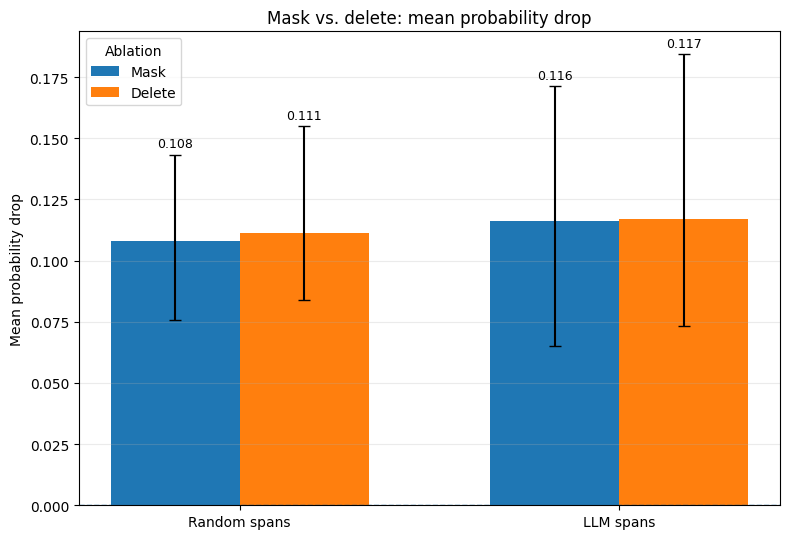

In [18]:
# Plot 1: Mean probability drop with 95% bootstrap confidence intervals.
plot_df = summary_argument_level.copy()

x = np.arange(len(METHOD_ORDER), dtype=float)
width = 0.34

fig, ax = plt.subplots(figsize=(8, 5.5))
for offset_index, ablation_mode in enumerate(ABLATION_ORDER):
    subset = (
        plot_df.loc[plot_df["ablation_mode"].eq(ablation_mode)]
        .set_index("method")
        .reindex(METHOD_ORDER)
    )
    means = subset["mean_prob_drop"].to_numpy(dtype=float)
    lower = means - subset["mean_prob_drop_ci95_low"].to_numpy(dtype=float)
    upper = subset["mean_prob_drop_ci95_high"].to_numpy(dtype=float) - means
    positions = x + (offset_index - 0.5) * width

    bars = ax.bar(
        positions,
        means,
        width=width,
        yerr=np.vstack([lower, upper]),
        capsize=4,
        label=ablation_mode.capitalize(),
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.axhline(0, linewidth=1, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER)
ax.set_ylabel("Mean probability drop")
ax.set_title("Mask vs. delete: mean probability drop")
ax.legend(title="Ablation")
ax.grid(axis="y", alpha=0.25)
save_current_figure("mean_probability_drop_mask_vs_delete.png")
plt.show()

Saved: results/ablation_comparison_random_llm/positive_drop_rate_mask_vs_delete.png


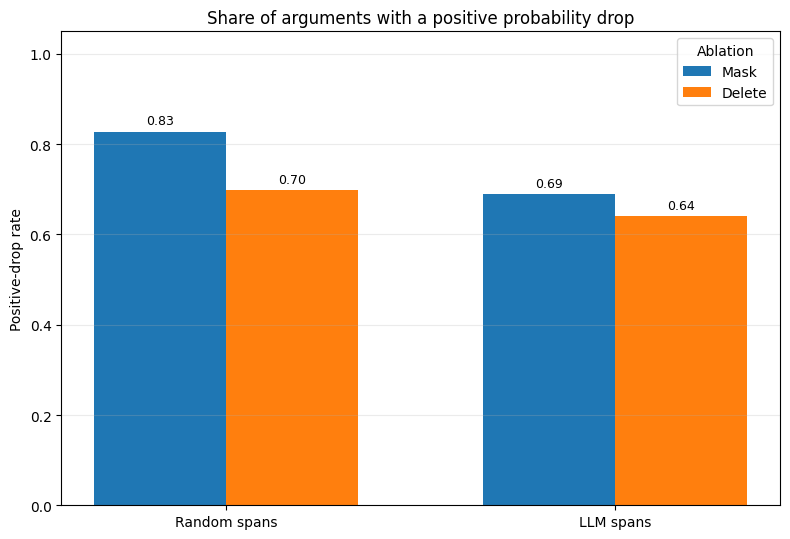

In [19]:
# Plot 2a: Positive-drop rate.
plot_df = summary_argument_level.copy()
x = np.arange(len(METHOD_ORDER), dtype=float)
width = 0.34

fig, ax = plt.subplots(figsize=(8, 5.5))
for offset_index, ablation_mode in enumerate(ABLATION_ORDER):
    subset = (
        plot_df.loc[plot_df["ablation_mode"].eq(ablation_mode)]
        .set_index("method")
        .reindex(METHOD_ORDER)
    )
    values = subset["positive_drop_rate"].to_numpy(dtype=float)
    positions = x + (offset_index - 0.5) * width
    bars = ax.bar(
        positions,
        values,
        width=width,
        label=ablation_mode.capitalize(),
    )
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)

ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER)
ax.set_ylabel("Positive-drop rate")
ax.set_title("Share of arguments with a positive probability drop")
ax.legend(title="Ablation")
ax.grid(axis="y", alpha=0.25)
save_current_figure("positive_drop_rate_mask_vs_delete.png")
plt.show()

Saved: results/ablation_comparison_random_llm/probability_drop_boxplots.png


/var/folders/9c/mdcbw50d74b4v7yjj79xw8yh0000gn/T/ipykernel_32815/701292903.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


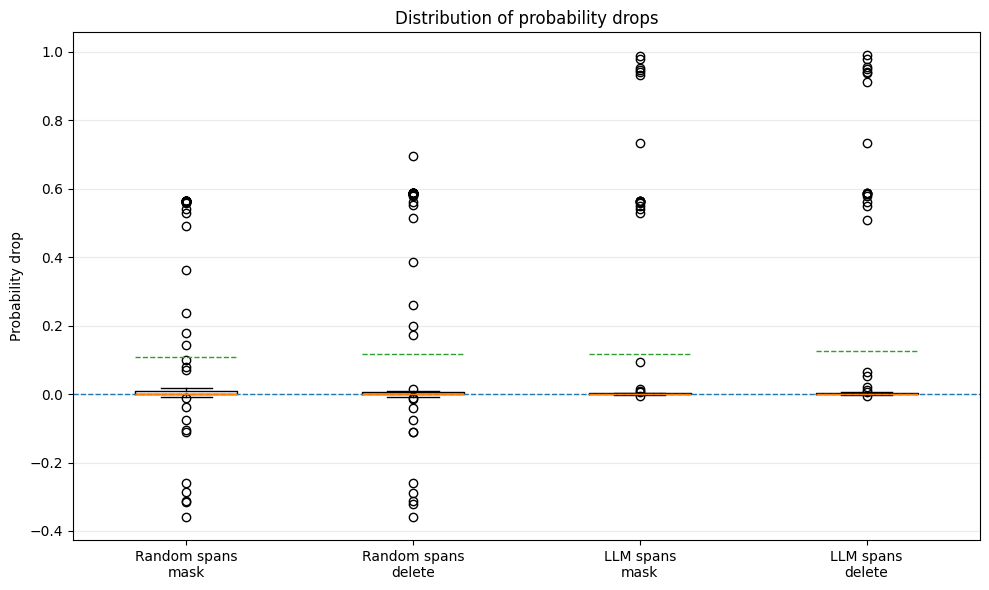

In [20]:
# Plot 3: Probability-drop distributions at argument level.
labels = []
values = []
for method in METHOD_ORDER:
    for ablation_mode in ABLATION_ORDER:
        subset = results_argument_level.loc[
            results_argument_level["method"].eq(method)
            & results_argument_level["ablation_mode"].eq(ablation_mode),
            "prob_drop",
        ].dropna()
        labels.append(f"{method}\n{ablation_mode}")
        values.append(subset.to_numpy())

fig, ax = plt.subplots(figsize=(10, 6))
box = ax.boxplot(
    values,
    labels=labels,
    showmeans=True,
    meanline=True,
    showfliers=True,
)
ax.axhline(0, linewidth=1, linestyle="--")
ax.set_ylabel("Probability drop")
ax.set_title("Distribution of probability drops")
ax.grid(axis="y", alpha=0.25)
save_current_figure("probability_drop_boxplots.png")
plt.show()

Saved: results/ablation_comparison_random_llm/paired_scatter_random_spans.png


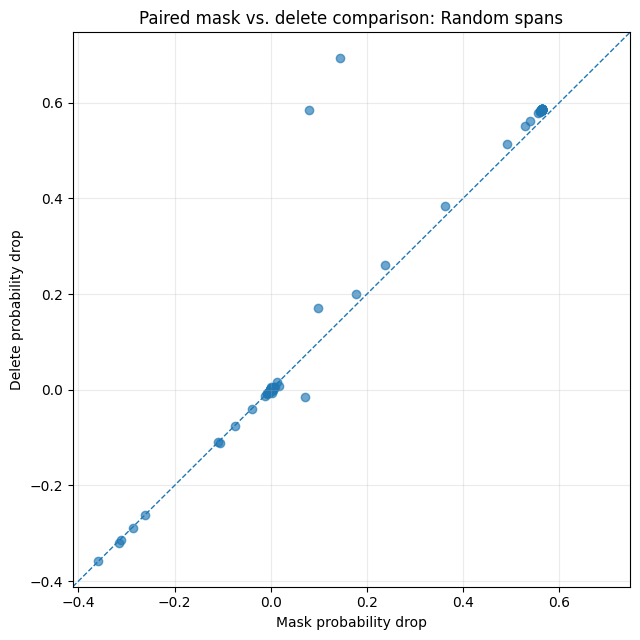

Saved: results/ablation_comparison_random_llm/paired_scatter_llm_spans.png


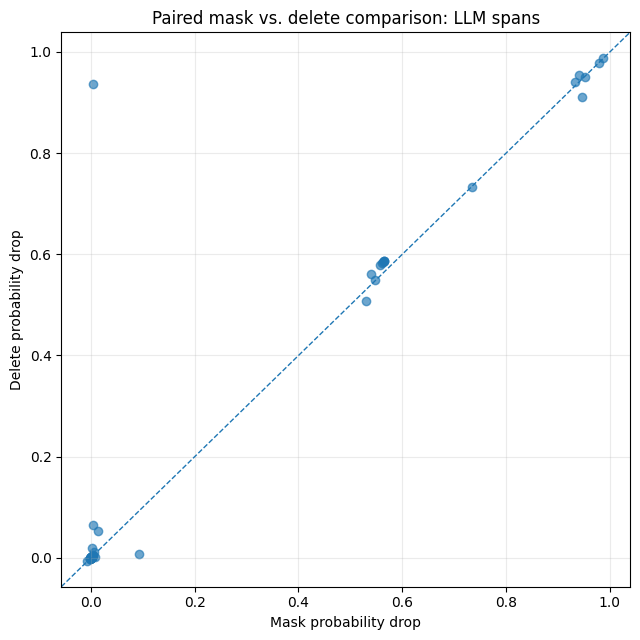

In [21]:
# Plot 4: Paired mask-vs-delete scatter plot for each method.
for method in METHOD_ORDER:
    method_df = results_argument_level.loc[
        results_argument_level["method"].eq(method)
    ]
    pivot = method_df.pivot(
        index="global_row_id",
        columns="ablation_mode",
        values="prob_drop",
    ).dropna(subset=["mask", "delete"])

    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.scatter(pivot["mask"], pivot["delete"], alpha=0.65)

    lower = float(np.nanmin(pivot[["mask", "delete"]].to_numpy()))
    upper = float(np.nanmax(pivot[["mask", "delete"]].to_numpy()))
    padding = max((upper - lower) * 0.05, 0.01)
    line_limits = [lower - padding, upper + padding]
    ax.plot(line_limits, line_limits, linestyle="--", linewidth=1)

    ax.set_xlim(line_limits)
    ax.set_ylim(line_limits)
    ax.set_xlabel("Mask probability drop")
    ax.set_ylabel("Delete probability drop")
    ax.set_title(f"Paired mask vs. delete comparison: {method}")
    ax.grid(alpha=0.25)
    save_current_figure(
        f"paired_scatter_{method.lower().replace(' ', '_')}.png"
    )
    plt.show()

Saved: results/ablation_comparison_random_llm/paired_difference_histogram_random_spans.png


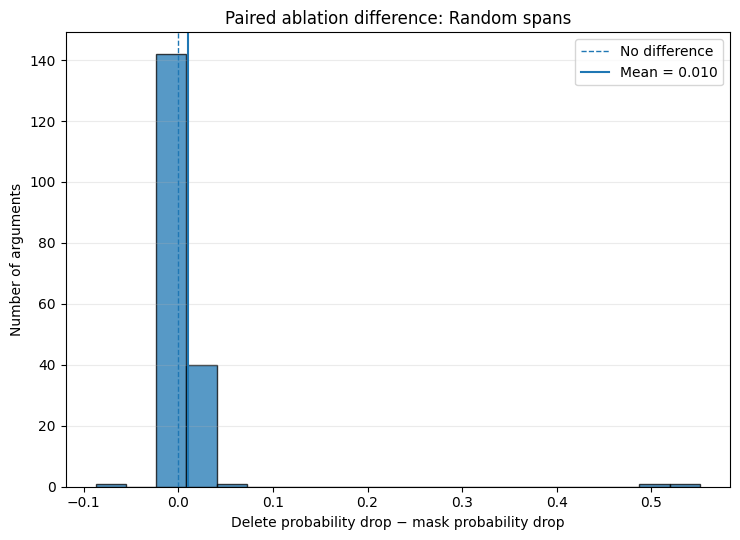

Saved: results/ablation_comparison_random_llm/paired_difference_histogram_llm_spans.png


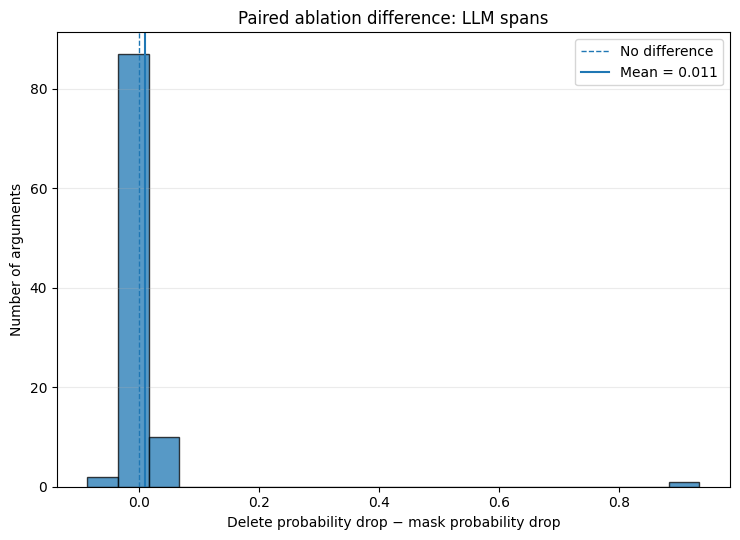

In [22]:
# Plot 5: Distribution of paired delete-minus-mask differences.
for method in METHOD_ORDER:
    method_df = results_argument_level.loc[
        results_argument_level["method"].eq(method)
    ]
    pivot = method_df.pivot(
        index="global_row_id",
        columns="ablation_mode",
        values="prob_drop",
    ).dropna(subset=["mask", "delete"])
    differences = pivot["delete"] - pivot["mask"]

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.hist(differences, bins=20, edgecolor="black", alpha=0.75)
    ax.axvline(0, linewidth=1, linestyle="--", label="No difference")
    ax.axvline(
        differences.mean(),
        linewidth=1.5,
        label=f"Mean = {differences.mean():.3f}",
    )
    ax.set_xlabel("Delete probability drop − mask probability drop")
    ax.set_ylabel("Number of arguments")
    ax.set_title(f"Paired ablation difference: {method}")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    save_current_figure(
        f"paired_difference_histogram_{method.lower().replace(' ', '_')}.png"
    )
    plt.show()

## 9. Optional comparison on common arguments only

This table is useful when the random and LLM files do not contain exactly the same arguments. It does not replace the within-method paired analysis; it only creates a stricter descriptive comparison across methods.

In [23]:
common_argument_results = results_argument_level.loc[
    results_argument_level["global_row_id"].isin(common_ids)
].copy()

if len(common_ids) > 0:
    common_summary = (
        common_argument_results
        .groupby(["method", "ablation_mode"], sort=False)
        .apply(summarize_group)
        .reset_index()
    )
    display(common_summary.round(4))
else:
    common_summary = pd.DataFrame()
    print("No common global_row_id values were found across the two methods.")

,method,ablation_mode,n_arguments,mean_p_inappropriate_original,mean_p_inappropriate_perturbed,mean_prob_drop,std_prob_drop,median_prob_drop,q25_prob_drop,q75_prob_drop,mean_prob_drop_ci95_low,mean_prob_drop_ci95_high,positive_drop_rate,prediction_flip_rate,mean_selected_token_ratio,mean_deleted_char_ratio,mean_n_spans
0,LLM spans,delete,100.0,0.9874,0.8605,0.1268,0.2879,0.0002,-0.0002,0.0024,0.0734,0.1845,0.64,0.17,0.2716,0.2646,2.04
1,LLM spans,mask,100.0,0.9874,0.8713,0.1160,0.2745,0.0002,-0.0001,0.0020,0.0650,0.1713,0.69,0.16,0.2716,0.2646,2.04
2,Random spans,delete,100.0,0.9874,0.8850,0.1024,0.2436,0.0003,-0.0001,0.0029,0.0583,0.1522,0.69,0.19,0.4839,0.4540,13.35
3,Random spans,mask,100.0,0.9874,0.8940,0.0934,0.2276,0.0008,0.0002,0.0033,0.0514,0.1411,0.81,0.18,0.4839,0.4540,13.35


## 10. Save all result tables

The method-specific files retain the original columns and add the deletion outputs. The combined files are suitable for downstream evaluation and thesis tables.

In [24]:
# Convert tuple spans to JSON strings before CSV export.
def serialize_spans_for_csv(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    if "char_spans" in out.columns:
        out["char_spans"] = out["char_spans"].map(json.dumps)
    if "span_texts_from_offsets" in out.columns:
        out["span_texts_from_offsets"] = out["span_texts_from_offsets"].map(
            json.dumps
        )
    return out


random_export = serialize_spans_for_csv(random_scored)
llm_export = serialize_spans_for_csv(llm_scored)

output_files = {
    "random_per_row": OUTPUT_DIR / "random_mask_vs_delete_per_row.csv",
    "llm_per_argument": OUTPUT_DIR / "llm_mask_vs_delete_per_argument.csv",
    "combined_long_raw": OUTPUT_DIR / "mask_vs_delete_long_row_level.csv",
    "combined_argument_level": OUTPUT_DIR / "mask_vs_delete_argument_level.csv",
    "summary_argument_level": OUTPUT_DIR / "mask_vs_delete_summary_argument_level.csv",
    "paired_statistics": OUTPUT_DIR / "mask_vs_delete_paired_statistics.csv",
    "sanity_checks": OUTPUT_DIR / "mask_vs_delete_sanity_checks.csv",
    "input_mode_validation": OUTPUT_DIR / "model_input_mode_validation.csv",
}

random_export.to_csv(output_files["random_per_row"], index=False)
llm_export.to_csv(output_files["llm_per_argument"], index=False)
results_long_raw.to_csv(output_files["combined_long_raw"], index=False)
results_argument_level.to_csv(output_files["combined_argument_level"], index=False)
summary_argument_level.to_csv(output_files["summary_argument_level"], index=False)
paired_summary.to_csv(output_files["paired_statistics"], index=False)
sanity_table.to_csv(output_files["sanity_checks"], index=False)
mode_results.to_csv(output_files["input_mode_validation"], index=False)

if not common_summary.empty:
    common_summary.to_csv(
        OUTPUT_DIR / "mask_vs_delete_common_arguments_summary.csv",
        index=False,
    )

print("Saved output files:")
for name, path in output_files.items():
    print(f"- {name}: {path}")

Saved output files:
- random_per_row: results/ablation_comparison_random_llm/random_mask_vs_delete_per_row.csv
- llm_per_argument: results/ablation_comparison_random_llm/llm_mask_vs_delete_per_argument.csv
- combined_long_raw: results/ablation_comparison_random_llm/mask_vs_delete_long_row_level.csv
- combined_argument_level: results/ablation_comparison_random_llm/mask_vs_delete_argument_level.csv
- summary_argument_level: results/ablation_comparison_random_llm/mask_vs_delete_summary_argument_level.csv
- paired_statistics: results/ablation_comparison_random_llm/mask_vs_delete_paired_statistics.csv
- sanity_checks: results/ablation_comparison_random_llm/mask_vs_delete_sanity_checks.csv
- input_mode_validation: results/ablation_comparison_random_llm/model_input_mode_validation.csv


## Interpretation guide

Use the results in the following order:

1. **Check input-mode reproduction first.** If the stored masking probabilities are not closely reproduced, fix the model configuration before interpreting deletion.
2. **Compare mean and median probability drop.** A larger positive value indicates a stronger reduction in the inappropriate-class probability.
3. **Inspect positive-drop rate.** This shows how consistently the ablation behaves in the intended direction.
4. **Inspect prediction-flip rate cautiously.** A flip is an intuitive but threshold-dependent measure and should not replace probability-based metrics.
5. **Use the paired difference.** `mean_delete_minus_mask > 0` favors deletion; a value below zero favors masking.
6. **Inspect the scatter plots and difference histograms.** They reveal whether an average advantage is broad or driven by a few outliers.
7. **Do not choose an ablation solely because it causes the largest drop.** Deletion can produce less natural or out-of-distribution inputs, while masking introduces a special token. The final choice should combine faithfulness results, consistency, and a methodological discussion of these perturbation artifacts.

For thesis reporting, the argument-level summary and paired statistics are preferable to row-level random-sample statistics.